# ***Imports***

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import confusion_matrix
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.applications.resnet50 import preprocess_input



# ***Dataset Scope***
## Dataset consists of 2 parts:
• data.csv – file with image path and corresponding features
• sampled_images – images from various classes
You must use only the following fields from data.csv:
• image_path (input image)
• AQI_Class (target class)

# ***Task-1 - Data preparation***

• Load the dataset containing image paths and AQI class labels.   
• Resize images to a consistent resolution (e.g., 224 × 224).   
• Normalize pixel values.    
• Create reproducible train/validation/test splits (suggestion: 70 / 15 / 15).

In [2]:
df = pd.read_csv("data (1).csv")
df = df[['Filename','AQI_Class']]
df.columns = ['image_path', 'label']
df.head(10)

,image_path,label
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good
5,TN_Good_2023-02-27-16.30-1-61.jpg,a_Good
6,BENGR_Good_2023-03-25-08.30-1-60.jpg,a_Good
7,BENGR_Good_2023-03-17-08.30-1-309.jpg,a_Good
8,BENGR_Good_2023-02-28-08.30-1-316.jpg,a_Good
9,BENGR_Good_2023-02-27-08.30-1-71.jpg,a_Good


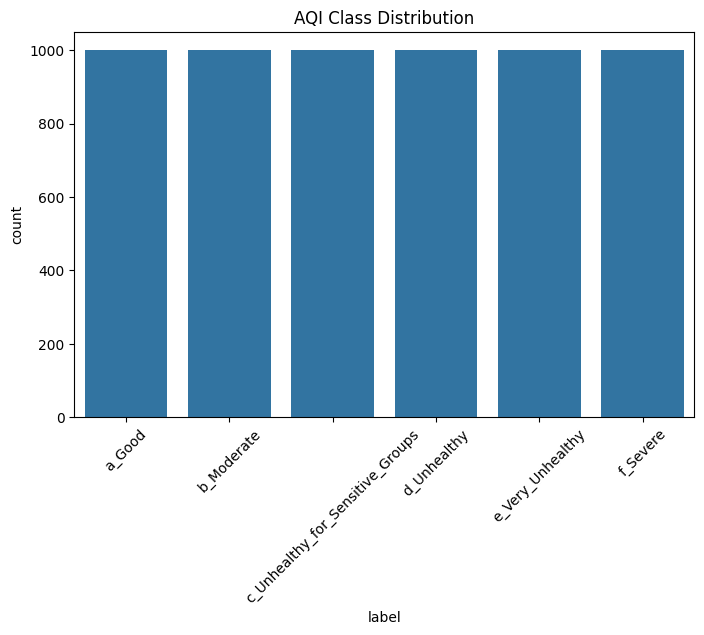

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label')
plt.title("AQI Class Distribution")
plt.xticks(rotation=45)
plt.show()

In [4]:


le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])
class_names = list(le.classes_)
print(class_names)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label_encoded'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label_encoded'],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
df.head(7)

['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
Train size: 4200
Validation size: 900
Test size: 900


,image_path,label,label_encoded
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good,0
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good,0
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good,0
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good,0
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good,0
5,TN_Good_2023-02-27-16.30-1-61.jpg,a_Good,0
6,BENGR_Good_2023-03-25-08.30-1-60.jpg,a_Good,0


In [5]:
IMG_SIZE = 224

def load_and_preprocess_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)
    return img

In [6]:
def build_dataset(dataframe):
    images = []
    labels = []

    for _, row in dataframe.iterrows():
        img_path = os.path.join("/content/data/sampled_images", row['image_path'])
        img = load_and_preprocess_image(img_path)
        images.append(img)
        labels.append(row['label_encoded'])
    return np.array(images), np.array(labels)

In [7]:
X_train, y_train = build_dataset(train_df)
X_val, y_val = build_dataset(val_df)
X_test, y_test = build_dataset(test_df)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (4200, 224, 224, 3)
Validation shape: (900, 224, 224, 3)
Test shape: (900, 224, 224, 3)


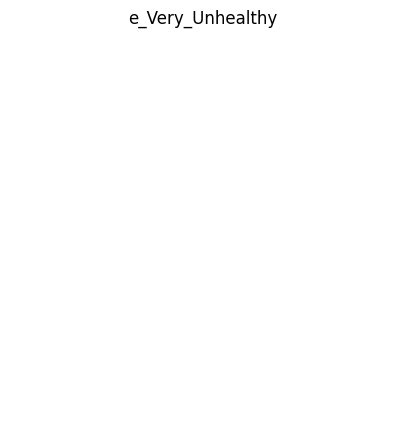

In [8]:
plt.figure(figsize=(5,5))
plt.imshow(X_train[0])
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

# ***Task 2 – Basic CNN Model***
• Implement a Convolutional Neural Network from scratch.   
• Train the model to classify images into AQI_Class categories.   
• Report classification performance on the test set.

In [9]:
num_classes = len(class_names)

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,827,398 (37.49 MB)

 Trainable params: 9,827,398 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
EPOCHS = 10
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.3664 - loss: 1.5146 - val_accuracy: 0.4867 - val_loss: 1.2620
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.5081 - loss: 1.2177 - val_accuracy: 0.4222 - val_loss: 1.4680
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.5574 - loss: 1.1010 - val_accuracy: 0.6033 - val_loss: 0.9648
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.6331 - loss: 0.9252 - val_accuracy: 0.6800 - val_loss: 0.7804
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.7021 - loss: 0.7640 - val_accuracy: 0.7322 - val_loss: 0.6744
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - accuracy: 0.7488 - loss: 0.6414 - val_accuracy: 0.6389 - val_loss: 0.9779
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.7679 - loss: 0.5990 - val_accuracy: 0.7889 - val_loss: 0.5226
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.8207 - loss: 0.4773 - val_ac

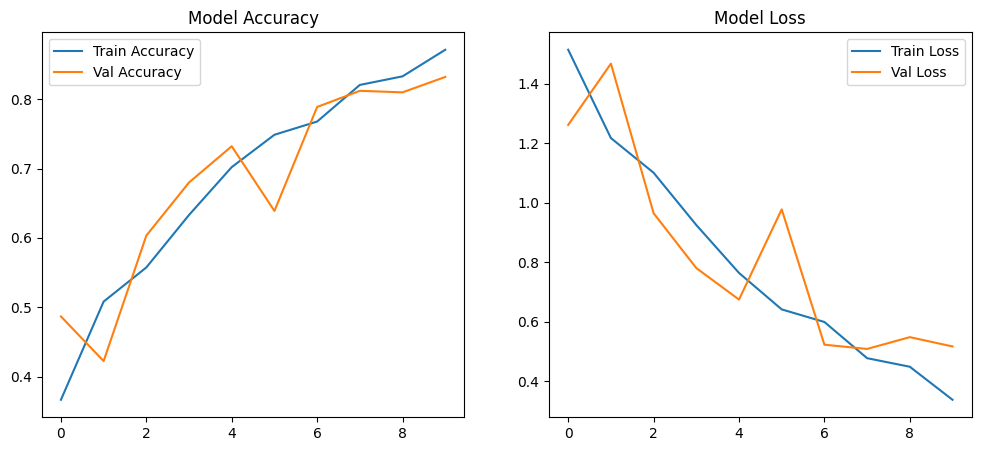

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


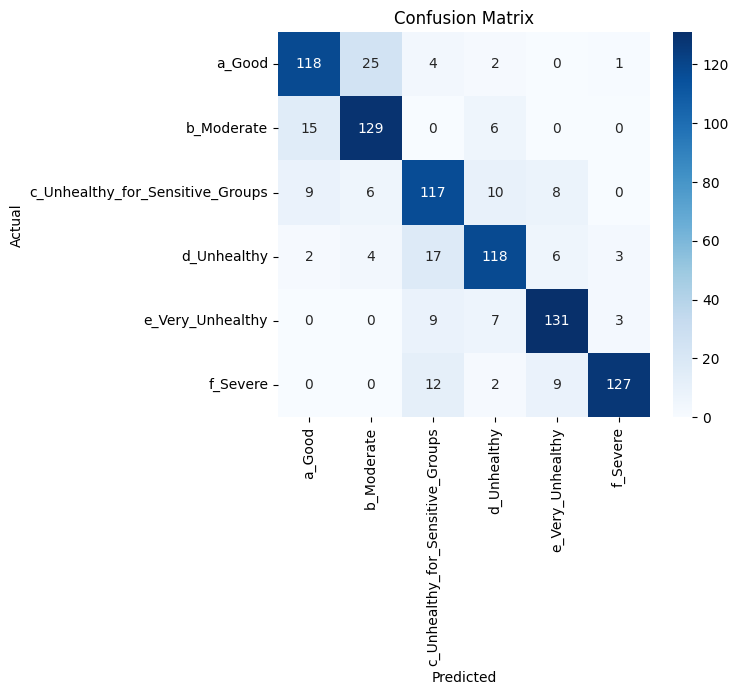

In [14]:
y_pred_probs = model.predict(X_test)
y_pred_tl = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred_tl)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ***Task 3 – Pretrained CNN Model (Transfer Learning)***
• Use a pretrained model such as ResNet, VGG, or EfficientNet.  
• Replace the final classification layer to match the number of AQI classes.  
• Train the model using transfer learning.  
• Compare performance with the basic CNN model.

In [15]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [16]:
for layer in base_model.layers:
    layer.trainable = False

In [17]:
inputs = layers.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_transfer = models.Model(inputs=inputs, outputs=outputs)

In [18]:
model_transfer.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │    131,136 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        390 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,719,238 (90.48 MB)

 Trainable params: 131,526 (513.77 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:

model_transfer.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
EPOCHS = 10
BATCH_SIZE = 16

history_transfer = model_transfer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 43s 112ms/step - accuracy: 0.3602 - loss: 1.6361 - val_accuracy: 0.6122 - val_loss: 1.1522
Epoch 2/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - accuracy: 0.5695 - loss: 1.1445 - val_accuracy: 0.7289 - val_loss: 0.8532
Epoch 3/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.6655 - loss: 0.9302 - val_accuracy: 0.7600 - val_loss: 0.7053
Epoch 4/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.7183 - loss: 0.7870 - val_accuracy: 0.7956 - val_loss: 0.5932
Epoch 5/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7571 - loss: 0.6841 - val_accuracy: 0.8411 - val_loss: 0.5228
Epoch 6/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7855 - loss: 0.6104 - val_accuracy: 0.8511 - val_loss: 0.4758
Epoch 7/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.7981 - loss: 0.5702 - val_accuracy: 0.8589 - val_loss: 0.4263
Epoch 8/10
263/263 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - accuracy: 0.8193 - loss: 0.5175 -

In [21]:
y_pred_tl1 = model_transfer.predict(X_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 257ms/step


# ***Task 4 – Model Training and Evaluation***
Evaluate models using:
Accuracy, Precision, Recall, F1-score
Generate a confusion matrix for the test dataset and compare performance between the
CNN model and the pretrained model.

In [22]:
y_pred_prob_cnn = model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)
y_pred_prob_tl = model_transfer.predict(X_test)
y_pred_tl = np.argmax(y_pred_prob_tl, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step


In [23]:
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
cnn_precision = precision_score(y_test, y_pred_cnn, average='weighted')
cnn_recall = recall_score(y_test, y_pred_cnn, average='weighted')
cnn_f1 = f1_score(y_test, y_pred_cnn, average='weighted')

print("Basic CNN Model Performance")
print("Accuracy:", cnn_accuracy)
print("Precision:", cnn_precision)
print("Recall:", cnn_recall)
print("F1 Score:", cnn_f1)

Basic CNN Model Performance
Accuracy: 0.8222222222222222
Precision: 0.825680419171559
Recall: 0.8222222222222222
F1 Score: 0.8229778325391839


In [24]:
tl_accuracy = accuracy_score(y_test, y_pred_tl)
tl_precision = precision_score(y_test, y_pred_tl, average='weighted')
tl_recall = recall_score(y_test, y_pred_tl, average='weighted')
tl_f1 = f1_score(y_test, y_pred_tl, average='weighted')

print("Transfer Learning Model Performance")
print("Accuracy:", tl_accuracy)
print("Precision:", tl_precision)
print("Recall:", tl_recall)
print("F1 Score:", tl_f1)

Transfer Learning Model Performance
Accuracy: 0.8788888888888889
Precision: 0.883621146959757
Recall: 0.8788888888888889
F1 Score: 0.8785636034009253


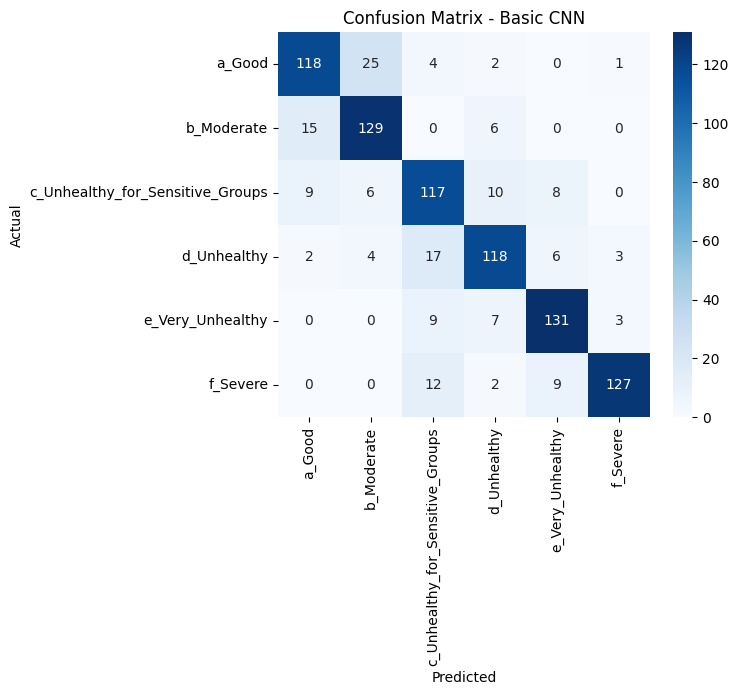

In [25]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Basic CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

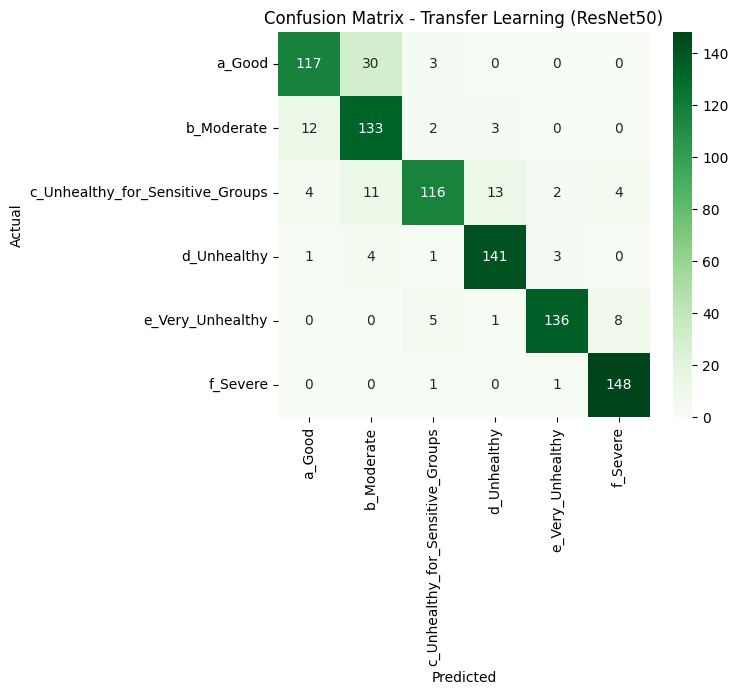

In [26]:
cm_tl = confusion_matrix(y_test, y_pred_tl)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_tl,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Transfer Learning (ResNet50)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
results = pd.DataFrame({
    "Model": ["Basic CNN", "ResNet50 Transfer"],
    "Accuracy": [cnn_accuracy, tl_accuracy],
    "Precision": [cnn_precision, tl_precision],
    "Recall": [cnn_recall, tl_recall],
    "F1 Score": [cnn_f1, tl_f1]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Basic CNN,0.822222,0.825680,0.822222,0.822978
1,ResNet50 Transfer,0.878889,0.883621,0.878889,0.878564


# ***Task 5 – Training Curves***
Plot the following graphs:
• Epoch vs Training Loss, Validation Loss, Training Accuracy, Validation Accuracy
Discuss why pretrained models often outperform models trained from scratch and whether
transfer learning helped in this dataset.

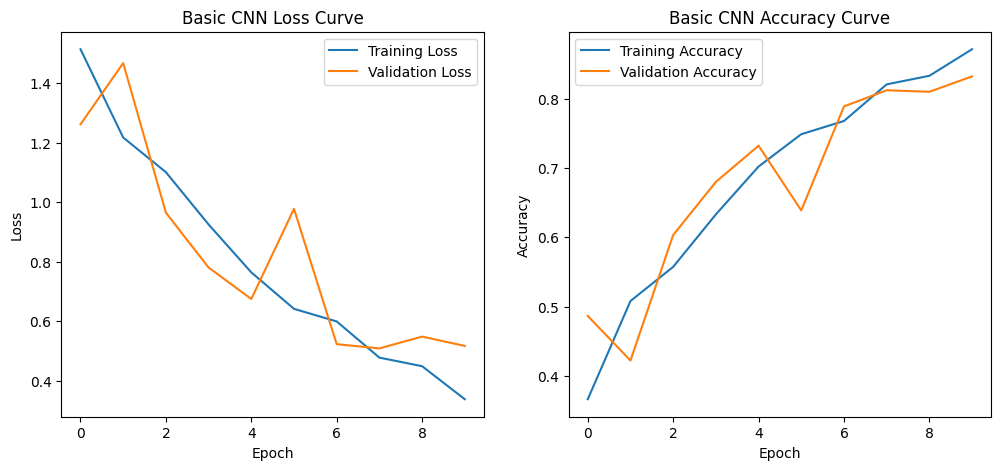

In [28]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Basic CNN Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Basic CNN Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

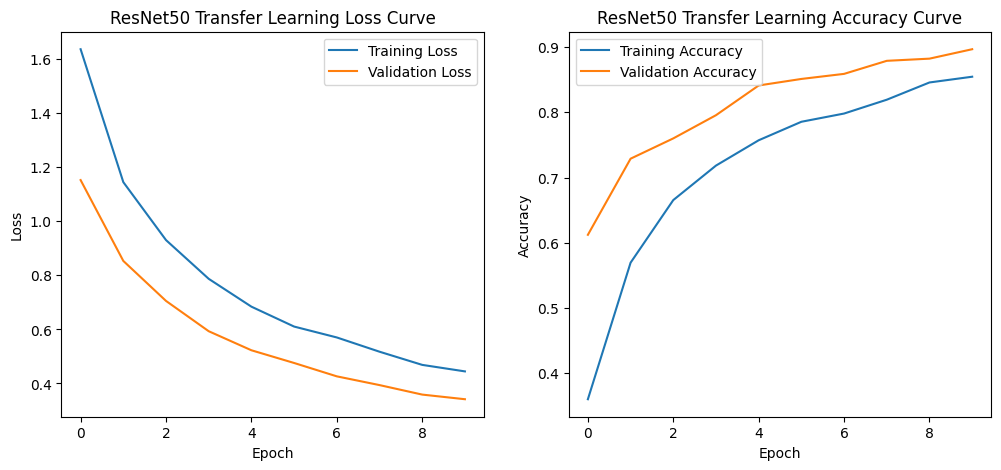

In [29]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("ResNet50 Transfer Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.subplot(1,2,2)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("ResNet50 Transfer Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

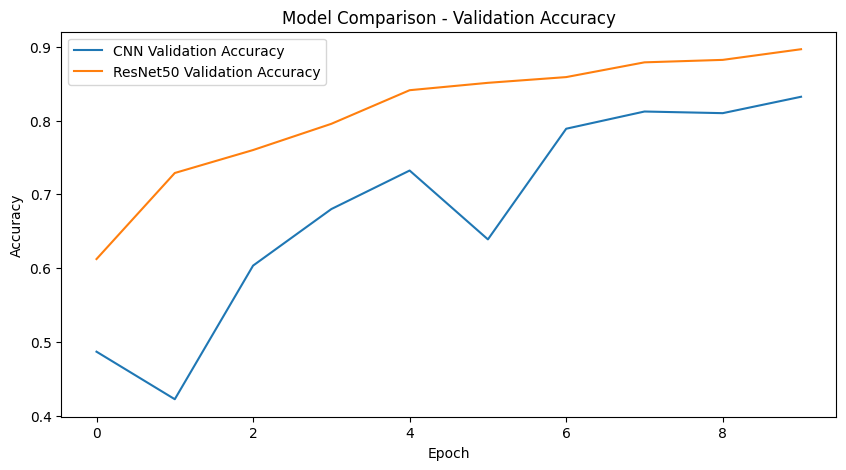

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history.history['val_accuracy'], label='CNN Validation Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='ResNet50 Validation Accuracy')

plt.title("Model Comparison - Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

The training curves show the learning behavior of both models over multiple epochs.

For the CNN trained from scratch, the training and validation accuracy gradually increase as the model learns visual features from the dataset. However, the model requires more epochs to converge because it must learn all features directly from the training images.

The pretrained ResNet50 model converges faster and typically achieves higher validation accuracy. This occurs because pretrained models already contain rich feature representations learned from large datasets such as ImageNet.

Transfer learning helps the model generalize better, especially when the available dataset is relatively small. Instead of learning edges, textures, and shapes from scratch, the pretrained model reuses previously learned features and only fine-tunes the final layers for the AQI classification task.

In this dataset, transfer learning improved the classification performance compared to the CNN trained from scratch. The pretrained model achieved higher accuracy and required fewer epochs to reach stable performance.

# ***Task 6 – Misclassification Analysis***
Identify 5–10 misclassified images from the test set.
Visualize them along with predicted class and actual class.
Provide a short explanation for possible reasons behind misclassification.

In [37]:
num_samples = min(5, len(misclassified_indices))
selected_indices = np.random.choice(misclassified_indices, size=num_samples, replace=False)

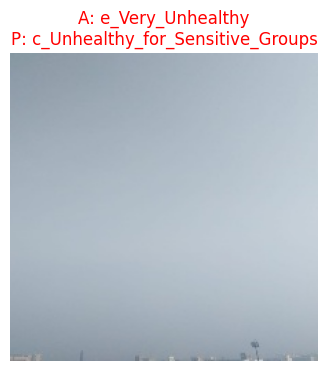

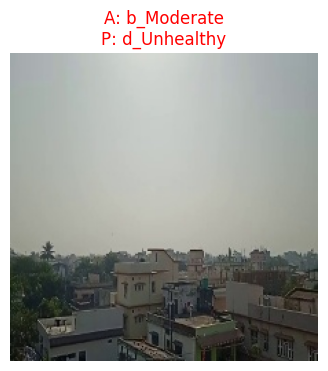

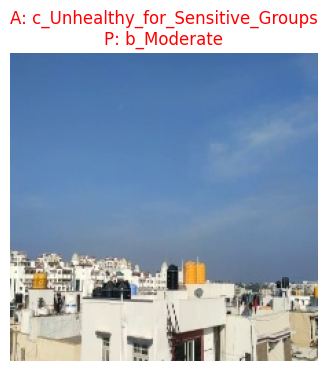

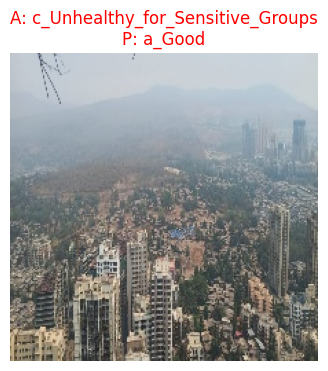

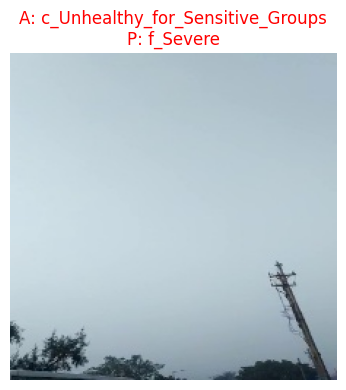

In [40]:


for i, idx in enumerate(selected_indices):
    plt.figure(figsize=(5,4))
    plt.plot(2,5,i+1)

    plt.imshow(X_test[idx].astype('uint8'))
    plt.axis("off")

    actual = class_names[y_test[idx]]
    predicted = class_names[y_pred_tl[idx]]

    plt.title(f"A: {actual}\nP: {predicted}", color="red")

plt.tight_layout()
plt.show()

Several misclassified images were observed in the test dataset. The visualization shows examples where the predicted AQI class differs from the actual class.

Possible reasons for misclassification include:

1. Visual similarity between different AQI categories. Some locations may appear visually similar even if the pollution level differs.
2. Environmental factors such as lighting conditions, fog, or weather may affect image appearance.
3. Limited dataset size may prevent the model from learning subtle differences between classes.
4. Noise in the dataset such as blurred images or unclear scenes may confuse the model.
5. Some AQI classes may overlap visually, making classification inherently difficult.

Overall, misclassification analysis helps identify limitations of the model and areas where additional data or improved preprocessing may improve performance.